In [2]:
!pip install blur-detector
from PIL import Image
import random
import cv2
import numpy as np
from blur_detector import detectBlur
import matplotlib.pyplot as plt

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for blur-detector: filename=blur_detector-0.0.6-py3-none-any.whl size=6277 sha256=3a109df2949042ef90666678815300bd4752feaa2144f470b46119b2f8c9c035
  Stored in directory: c:\users\user\appdata\local\pip\cache\wheels\32\30\84\898d48fea608036dc8e35fa5d103777331ee7f6fe2dc3634e6
Successfully built blur-detector


Before inserting Data:  [125 137 226]


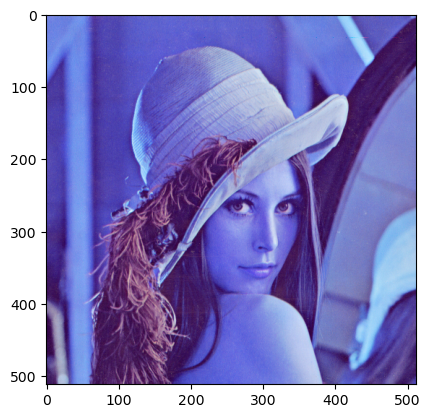

In [18]:
img_color=cv2.imread('lenna.png')
plt.imshow(img_color)
b,g,r=cv2.split(img_color)

print("Before inserting Data: ",img_color[1,0])

In [19]:
# msg="HelloWorldHelloWorldHelloWorldHelloWorldHelloWorldHelloWorldHelloWorldHelloWorldHelloWorldHelloWorldHelloWorld"
msg="HelloWorldHelloWorldHelloWorld"
msg_bin="".join(format(ord(i),'08b') for i in msg)
print(msg_bin)
msg_bin = [int(x) for x in msg_bin]
msg_len=len(msg_bin)


width=img_color.shape[0]
height=img_color.shape[1]
# print(width)
pixel=width*height*3
# print(pixel)

010010000110010101101100011011000110111101010111011011110111001001101100011001000100100001100101011011000110110001101111010101110110111101110010011011000110010001001000011001010110110001101100011011110101011101101111011100100110110001100100


_____BLUE_____
[|                  ] 10%
[| |                ] 20%
[| | |              ] 30%
[| | | |            ] 40%
[| | | | |          ] 50%
[| | | | | |        ] 60%
[| | | | | | |      ] 70%
[| | | | | | | |    ] 80%
[| | | | | | | | |  ] 90%


[0, 1, 2, 3, 4, 5, 6, 512, 513, 514, 515, 516, 517, 518, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1536, 1537, 1538, 1539, 1540, 1541, 1542, 2048, 2049, 2050, 2051, 2052, 2053, 2054, 2560, 2561, 2562, 2563, 2564, 2565, 2566, 3072, 3073, 3074, 3075, 3076, 3077, 157696, 157697, 157698, 157699, 157700, 158208, 158209, 158210, 158211, 158212, 158213, 158720, 158721, 158722, 158723, 158724, 158725, 159232, 159233, 159234, 159235, 159236, 159237, 159744, 159745, 159746, 159747, 159748, 159749, 160256, 160257, 160258, 160259, 160260, 160261, 160768, 160769, 160770, 160771, 160772, 160773, 161280, 161281, 161282, 161283, 161284, 161285, 161792, 161793, 161794, 161795, 161796, 161797, 162304, 162305, 162306, 162307, 162308, 162309, 162816, 162817, 

True

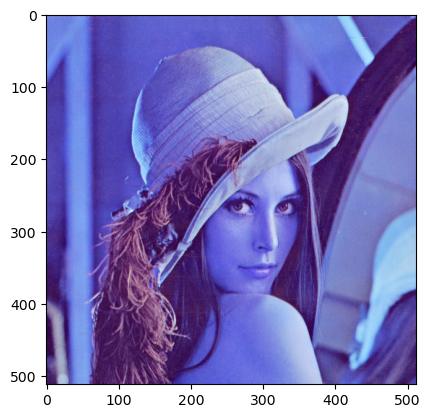

In [20]:
blue=True
# blue=False

green=True
# green=False

red=True
# red=False


if blue==True:
    print("_____BLUE_____")
    is_blurry_b=detectBlur(b)
    blur_b=[]
    if is_blurry_b.all():
        blur_b.append(is_blurry_b)
        print("\n")

        pos_index=[]
        new_blur_b=np.array(blur_b).flatten()
        for index,i in enumerate(new_blur_b):
            blur=np.less(i,0.1)
            if blur.all():
                pos_index.append(index)
        print(pos_index)
channel=[0,1,2]
counter=0
for i in range(3):
    for px,msg_bit in zip(pos_index,msg_bin):
        row=px//width%width
        col=px%height
        print("%5d %10d %15d" %(px,row,col))
        npx=img_color[row,col,0]
        print("old:",bin(npx)+"\t",npx)
        npx_lsb=npx & ~1 | msg_bit
        print("************",bin(npx_lsb)+"\t",npx_lsb)
        img_color[row,col,0]=npx_lsb
    for px,msg_bit in zip(pos_index,msg_bin):
        row=px//width%width
        col=px%height
        print("%5d %10d %15d" %(px,row,col))
        npx=img_color[row,col,1]
        print("old:",bin(npx)+"\t",npx)
        npx_lsb=npx & ~1 | msg_bit
        print("************",bin(npx_lsb)+"\t",npx_lsb)

        img_color[row,col,1]=npx_lsb
    for px,msg_bit in zip(pos_index,msg_bin):
        row=px//width%width
        col=px%height
        print("%5d %10d %15d" %(px,row,col))
        npx=img_color[row,col,2]
        print("old:",bin(npx)+"\t",npx)

        npx_lsb=npx & ~1 | msg_bit
        print("************",bin(npx_lsb)+"\t",npx_lsb)
        img_color[row,col,2]=npx_lsb

    
plt.imshow(img_color)
print("After inserting Data: ",img_color[1,0])
img_ori=cv2.cvtColor(img_color,cv2.COLOR_BGR2RGB)
# cv2.imwrite("SVI_Color_Lenna_new.png",img_color)
cv2.imwrite("Blur_steg_lenna.png",img_color)
